In [3]:
import numpy as np
import pandas as pd
from src.processing import calculate_fitness, find_pareto_front
from src.visualization import display_pareto_front, display_fitness_landscape_with_pareto

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5


In [ ]:
total_records = 10000000

equations1 = [
    lambda x: (x/500000)**2 / 40,
    lambda x: 10 * np.cos(x/30000000),
    lambda x: 7 * np.cos(x/10000000),
    lambda x: 4 * np.cos(x/4000000),
    lambda x: 5 * np.cos(x/1000000),
    lambda x: 5 * np.cos(x/500000),
    lambda x: 4 * np.sin(x/100000),
    lambda x: 3 * np.cos(x/25000),
    lambda x: 2 * np.cos(x/4000),
    lambda x:     np.sin(x/2000),
    lambda x: np.maximum(0, 3 * np.cos(2.3+ (x/10000))),
    lambda x: np.maximum(0, 3 * np.sin(1  + (x/10000))),
    lambda x: 5,
]

equations2 = [
    lambda x: (x/420000)**2 / 15,
    lambda x: 10 * np.sin(x/30000000),
    lambda x: 7 * np.sin(x/10000000),
    lambda x: 2 * np.sin(x/4000000),
    lambda x: 2 * np.sin(x/2000000),
    lambda x: 2 * np.sin(x/1000000),
    lambda x: 2 * np.cos(x/300000),
    lambda x: 2 * np.cos(x/50000),
    lambda x:     np.sin(x/20000),
    lambda x:     np.cos(x/8000),
    lambda x: np.minimum(0, 3 * np.cos(2.3+ (x/10000))),
    lambda x: np.minimum(0, 3 * np.sin(1  + (x/10000))),
    lambda x: 5,
]

Total de registros: 10,000,000
Range: 0 até 9,999,999
Calculando fitness de forma matricial...
✅ Cálculo matricial concluído!
Colunas: ['registro', 'eq1_0', 'eq1_1', 'eq1_2', 'eq1_3', 'eq1_4', 'eq1_5', 'eq1_6', 'eq1_7', 'eq1_8', 'eq1_9', 'eq1_10', 'eq1_11', 'eq1_12', 'eq2_0', 'eq2_1', 'eq2_2', 'eq2_3', 'eq2_4', 'eq2_5', 'eq2_6', 'eq2_7', 'eq2_8', 'eq2_9', 'eq2_10', 'eq2_11', 'eq2_12', 'fitness1', 'fitness2', 'fitness_full']
Encontrando fronteira de Pareto...
Total de pontos no espaço de busca: 10,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 20,118 pontos.
Isso representa 0.2012% do espaço de busca.


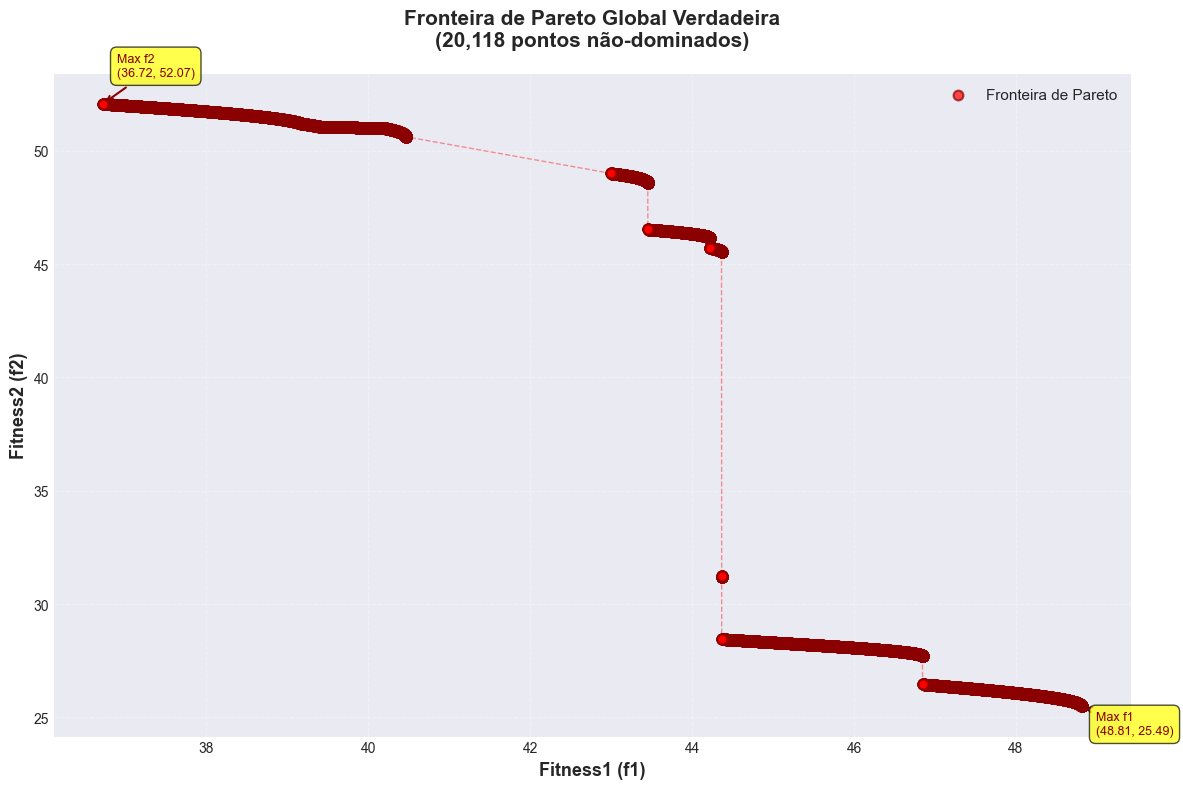


✅ Visualização concluída!


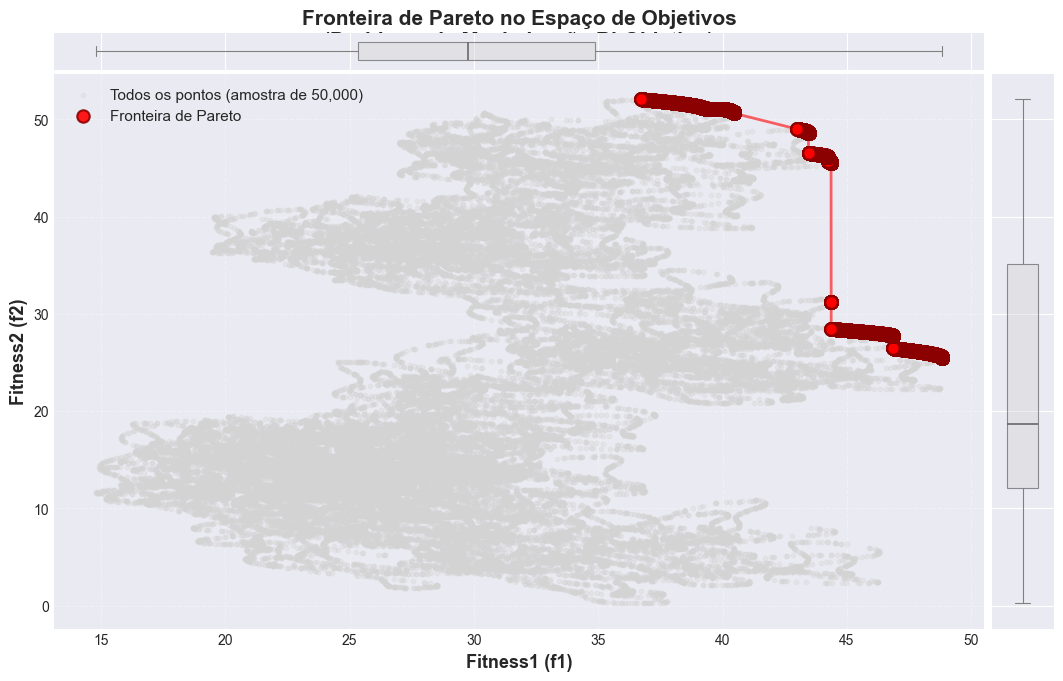

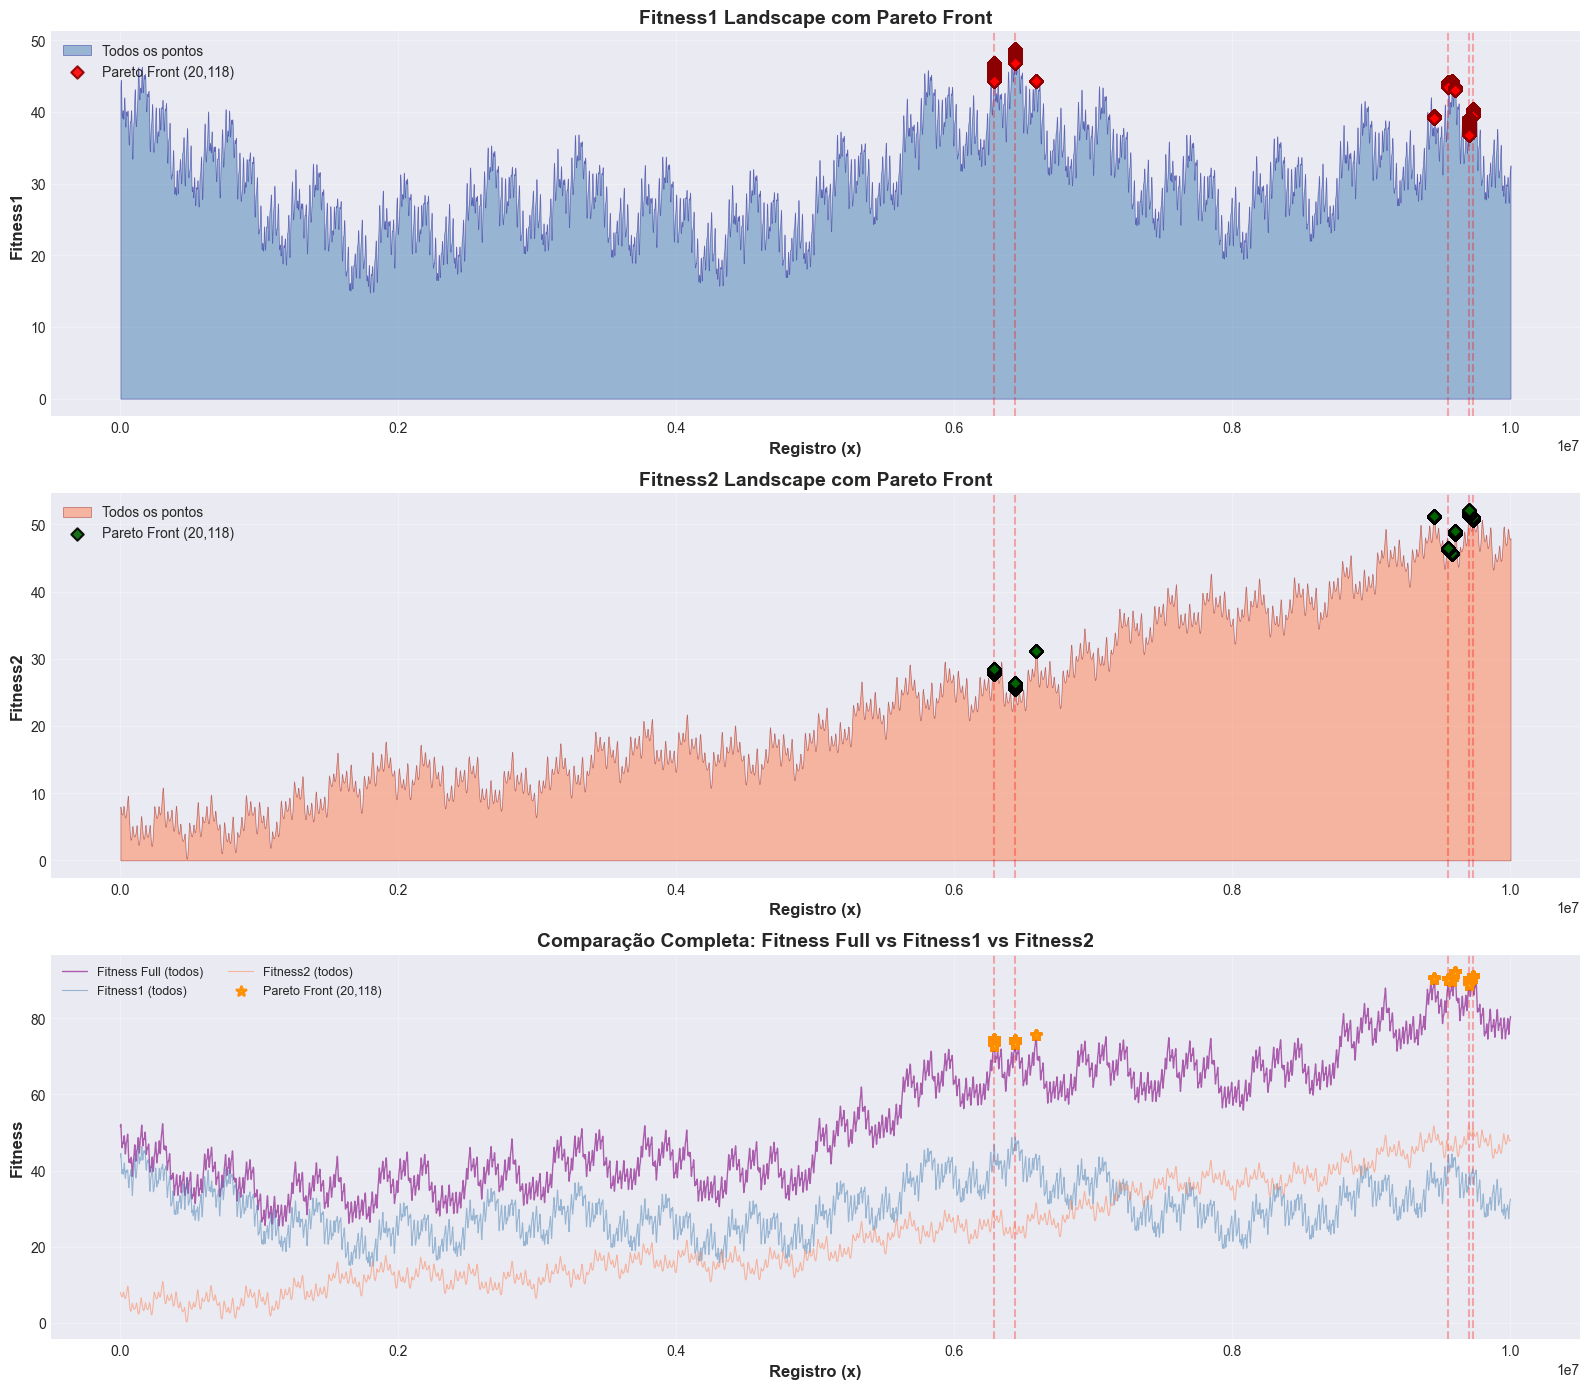

In [5]:
#### Criando dataframe com registros de 0 a 9999999
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
df = pd.DataFrame({'registro': registros})

print(f"Total de registros: {len(registros):,}")
print(f"Range: {registros[0]:,} até {registros[-1]:,}")

#### Calculando fitness de forma matricial
print("Calculando fitness de forma matricial...")
df = calculate_fitness(equations1, equations2, df)
df['fitness_full'] = df['fitness1'] + df['fitness2']

print(f"✅ Cálculo matricial concluído!")
print(f"Colunas: {list(df.columns)}")

#### Encontrando a fronteira de Pareto verdadeira
pareto_df = find_pareto_front(df)
display_pareto_front(df, pareto_df)
display_fitness_landscape_with_pareto(df, pareto_df)

#### Salvando resultados
df.to_parquet('data/df.parquet')
pareto_df.to_parquet('data/pareto_df.parquet')

# df2 lab

In [ ]:
df2 = df.copy()
df2['fitness1'] = 3 + 0.8 * np.log2(df2['registro']+2)*df2['fitness1']/30
df2['log'] = (df2['registro']+2)**2
df2

In [ ]:
#plt.plot(df2['registro'], df2['log'], label='log')
plt.plot(df2['registro'], df2['fitness1'], label='fitness1')
plt.plot(df2['registro'], df2['fitness2'], label='fitness2')
plt.plot(df2['registro'], df2['log'], label='log')
plt.xlabel('registro')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
#pareto_df = find_pareto_front(df2)
#display_pareto_front(df2, pareto_df)
#display_fitness_landscape_with_pareto(df2, pareto_df)